# HistoMap Tutorial: Tissue detection

This notebook demonstrates how to use the HistoMapTx package to analyze spatial transcriptomics data from 10x Genomics Visium platform. HistoMap helps integrate histological annotations with spatial gene expression data, enabling tissue region-specific analysis.

## Overview

In this tutorial, we will:
1. Load Visium spatial transcriptomics data using SpatialData
2. Import histological annotations from QuPath
3. Create a HistoMap object that combines annotations with gene expression data
4. Perform tissue detection and filtering
6. Export filtered data for downstream analysis

Let's get started!

## Setting up the environment

First, let's import the necessary libraries and suppress warnings to keep our notebook clean.

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Import required libraries
import spatialdata  # For handling spatial data objects
import spatialdata_io  # For reading spatial data formats
import HistoMapTx as hm  # Main package for annotation integration
import matplotlib.pyplot as plt  # For visualization

# Set figure size for better visualization
plt.rcParams['figure.figsize'] = [12, 10]

## Creating a HistoMap

To create a HistoMap, we need three key inputs:

1. **SpaceRanger output**: Loaded as a SpatialData object
2. **Annotation file**: Generated with QuPath and saved as a GeoJSON file
3. **Full resolution image**: The same image that was used in the SpaceRanger pipeline

### Making annotations with QuPath

QuPath is a powerful tool for histological image annotation. You can create annotations by:
- Drawing regions of interest manually
- Using automatic tissue detection algorithms
- Applying cell detection and classification

For detailed instructions:
- [QuPath documentation](https://qupath.readthedocs.io/en/stable/docs/starting/annotating.html)
- [Video tutorial](https://www.youtube.com/watch?v=vr9w_LYtSso)

### Loading Visium Data

In [2]:
# Path to your Visium dataset folder (containing the SpaceRanger output)
visium_path = '/home/croizer/Documents/Curie/ressources/4_visium_section/2_HGSOC/2_Run2_Geraldine/VISIUM2/AO5603_NIP_0085020/'

# Path to QuPath annotation GeoJSON file
annotation_file = "/home/croizer/Téléchargements/QuPath-v0.5.1-Linux/Project1/AO5603_NIP_0085020_final.geojson.gz"

# Path to full resolution TIFF image (the one used for annotation and SpaceRanger)
full_res_image = "/home/croizer/Documents/Curie/ressources/4_visium_section/2_HGSOC/2_Run2_Geraldine/VISIUM2/images/AO5603_NIP_0085020.tiff"

In [3]:
# Load the Visium data using spatialdata_io
visium = spatialdata_io.visium(visium_path, dataset_id='AO1124')

INFO     reading                                                                                                   
         /home/croizer/Documents/Curie/ressources/4_visium_section/2_HGSOC/2_Run2_Geraldine/VISIUM2/AO5603_NIP_0085
         020/filtered_feature_bc_matrix.h5                                                                         


### Creating the HistoMap Object

Now that we have loaded our data, we can create a HistoMap object that integrates the annotations with the spatial transcriptomics data.

In [4]:
# Create a HistoMap object by combining the annotation file, Visium data, and the full resolution image
histomap = hm.HistoMap(annotation_file, visium, full_res_image)

# Display information about the HistoMap object
print(histomap)

HistoMap Object

--------Annotation--------
📂 Annotation file used: /home/croizer/Téléchargements/QuPath-v0.5.1-Linux/Project1/AO5603_NIP_0085020_final.geojson.gz
📂 Full resolution image used: /home/croizer/Documents/Curie/ressources/4_visium_section/2_HGSOC/2_Run2_Geraldine/VISIUM2/images/AO5603_NIP_0085020.tiff
🔢 Number of annotations present: 6
🏷 Annotations: Necrosis, Negative, Positive, Stroma, Tumor, giant_cells
🏷 Activated annotations: Necrosis, giant_cells, Stroma, Tumor, Negative, Positive
🏷 Disabled annotations: 

-------Spatial Data--------
SpatialData object
├── Images
│     ├── 'AO1124_hires_image': DataArray[cyx] (3, 1970, 2000)
│     └── 'AO1124_lowres_image': DataArray[cyx] (3, 591, 600)
├── Shapes
│     └── 'AO1124': GeoDataFrame shape: (3260, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (3260, 36601)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        AO1124_hires_image (Images), AO1124 (Shapes)
    ▸ 'downscaled_lowres', with elements:
 

## Visualizing Annotations

Let's visualize the annotations we've imported from QuPath on the tissue image. This helps us confirm that the annotations are correctly aligned with the tissue.

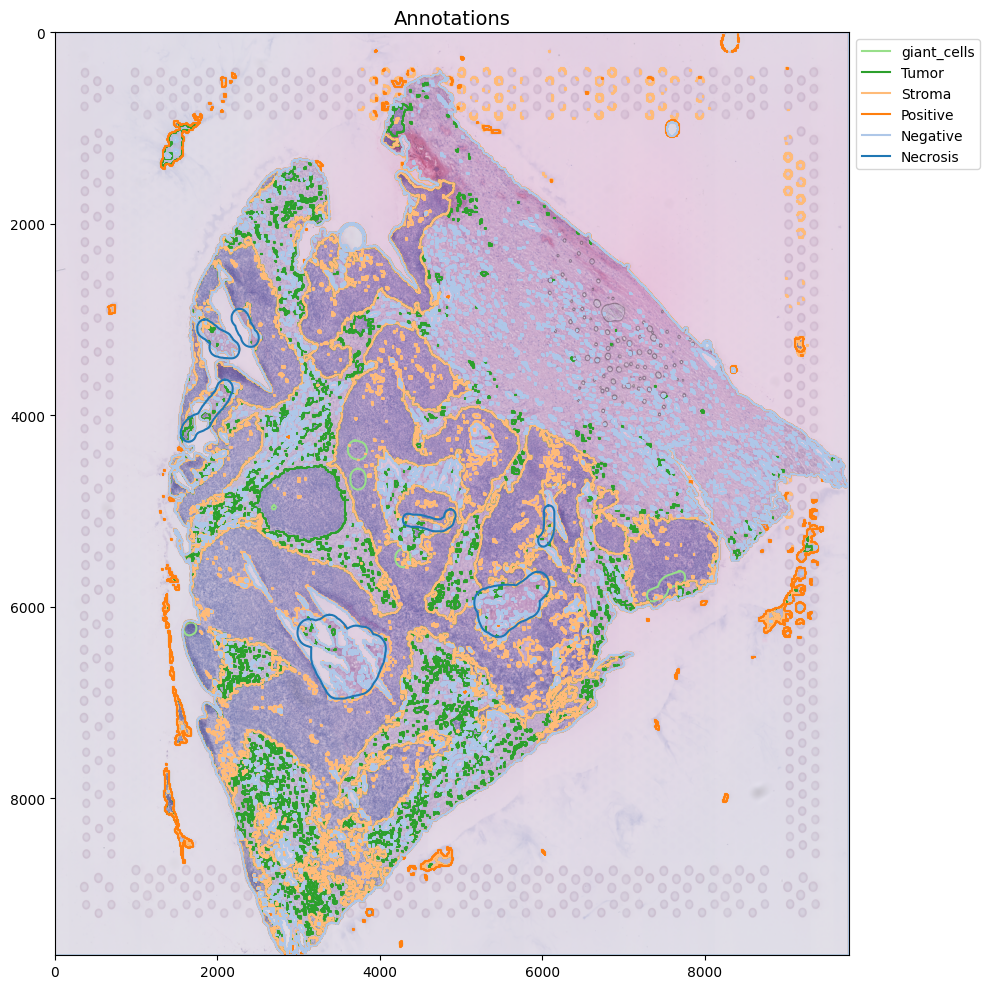

In [5]:
# Plot all annotations on the tissue image
hm.plot_annotations(histomap, display_image=True)

### Annotation Properties

We can generate a summary of our annotations to understand their properties, including total area, perimeter, and number of components in each annotation category.

In [6]:
# Generate summary statistics for all annotations
annotation_summary = histomap.generate_summary()
annotation_summary

,Annotation,total_area,total_perimeter,polygon_count,area_fraction
0,Necrosis,1.518808e+06,12879.016521,7,0.011342
1,Negative,5.679027e+07,437216.000000,2071,0.424091
2,Positive,3.752749e+07,417968.000000,164,0.280243
3,Stroma,2.112634e+07,855328.000000,2142,0.157764
4,Tumor,1.676595e+07,495168.000000,1465,0.125203
5,giant_cells,1.817278e+05,3759.987613,6,0.001357


## Tissue Detection and Filtering

In spot-based spatial transcriptomics technologies like Visium, the capture area may include regions without tissue or with poor quality tissue. We can use annotations to identify and filter these spots.

### Visualizing Tissue Detection Annotations

Let's first visualize the annotations we'll use for tissue detection. In this example, we have both "Positive" and "Negative" annotations.

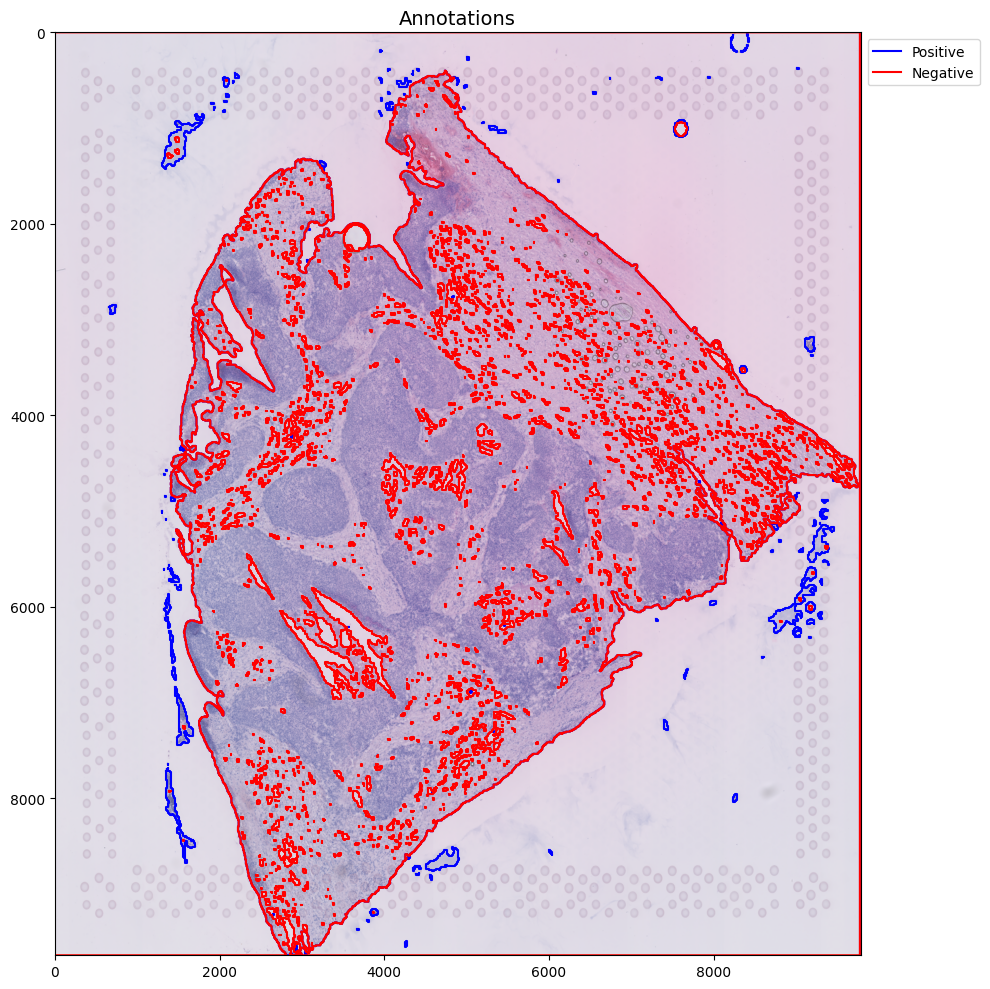

In [7]:
# Plot only the Positive and Negative annotations (used for tissue detection)
hm.plot_annotations(histomap, annotation=["Positive", 'Negative'], display_image=True, contour=['blue', 'red'])

### Computing Tissue Overlap

Now we'll compute how much each spot overlaps with the tissue. We can specify:
- A positive annotation that covers the tissue
- An optional negative annotation that should be subtracted (e.g., holes in the tissue)

The function calculates what percentage of each spot is covered by actual tissue.

In [8]:
# Calculate tissue overlap for each spot
# positive: annotation indicating tissue presence
# negative: annotation indicating holes or areas to exclude
histomap.compute_tissue_overlap(positive='Positive', negative='Negative')

1/1 layer of annotation processed: Positive
Updated 'Annotation_positive' for 'Positive' with threshold 50%.
Computed annotation overlap for: Positive. Updated Overlay status.
1/1 layer of annotation processed: Negative
Updated 'Annotation_positive' for 'Negative' with threshold 50%.
Computed annotation overlap for: Negative. Updated Overlay status.


### Visualizing Tissue Overlap

Let's visualize the tissue overlap to see which spots have good coverage and which ones have poor coverage.

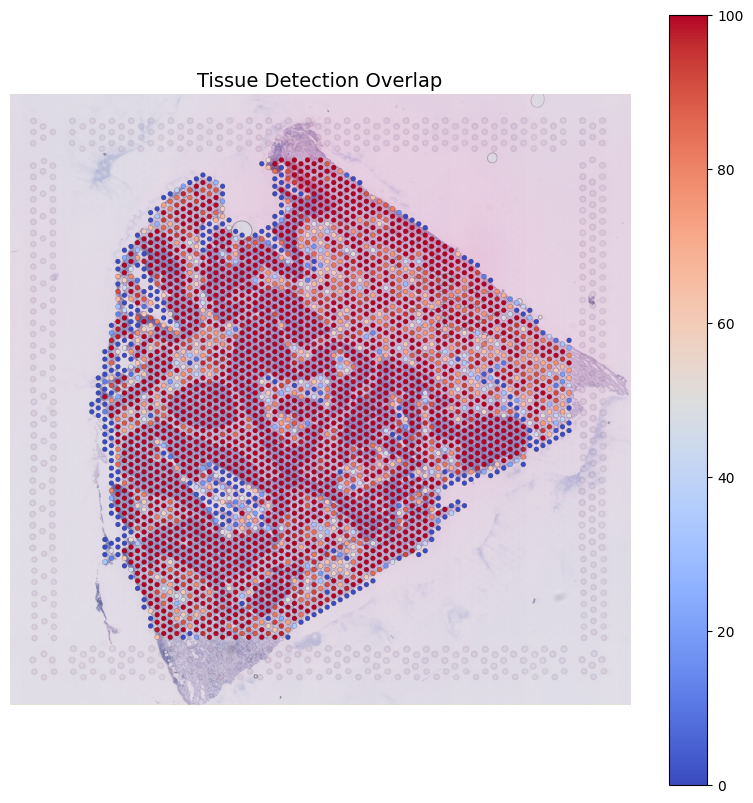

In [9]:
# Plot tissue overlap as a heatmap on the tissue image
hm.plot_tissue_overlap(histomap, display_image=True)

### Distribution of Tissue Overlap

We can also visualize the distribution of tissue overlap values using a violin plot.

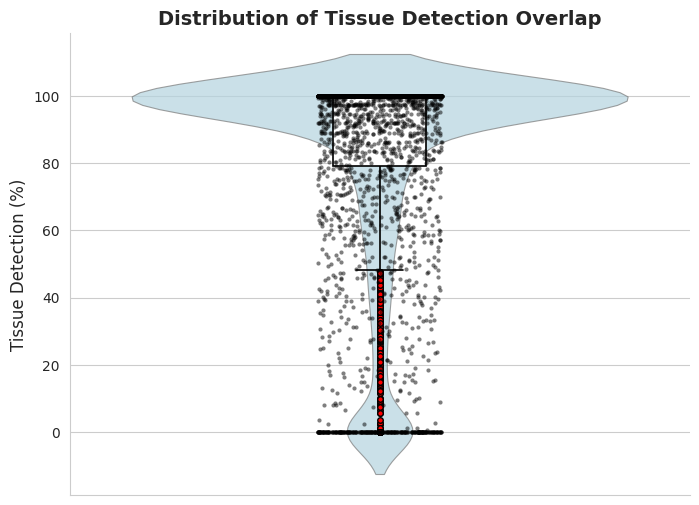

In [10]:
# Create a violin plot showing the distribution of tissue overlap percentages
hm.violin_tissue_overlap(histomap)

### Tissue Coverage Statistics

Let's examine the statistics of tissue coverage across all spots.

In [11]:
# Generate summary statistics for tissue coverage
histomap.tissue_detection_summary()

,count,mean,std,min,25%,50%,75%,max
Tissue Detection Statistics,3260.0,82.162722,31.239032,0.0,79.078541,100.0,100.0,100.0


There is 2161 spots in our spatial object, with a tissue mean coverage of 67%, with some spot covering no tissue. 

### Filtering Spots Based on Tissue Coverage

Now that we understand the tissue coverage, we can filter out spots with poor coverage (e.g., spots that are mostly outside the tissue). This improves the quality of our analysis by ensuring we only include spots with sufficient tissue.

In [12]:
# Filter spots to keep only those with at least 50% tissue coverage
histomap_filtered = histomap.filter_tissue_overlap(threshold=50) 

### Visualizing Filtered Spots

Let's see how our filtered data looks. Only spots with sufficient tissue coverage should remain.

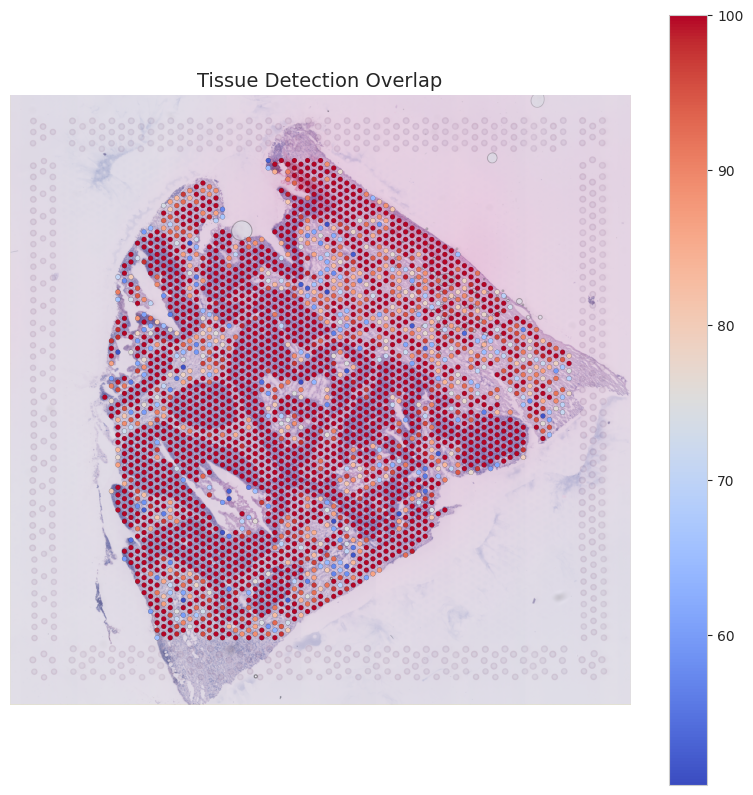

In [13]:
# Plot tissue overlap after filtering
hm.plot_tissue_overlap(histomap_filtered, display_image=True)

### Filtered Data Statistics

Let's check the statistics of our filtered dataset to confirm that low-quality spots have been removed.

In [14]:
# Generate tissue coverage statistics for filtered data
histomap_filtered.tissue_detection_summary()

,count,mean,std,min,25%,50%,75%,max
Tissue Detection Statistics,2773.0,94.157348,11.335622,50.360702,94.046729,100.0,100.0,100.0


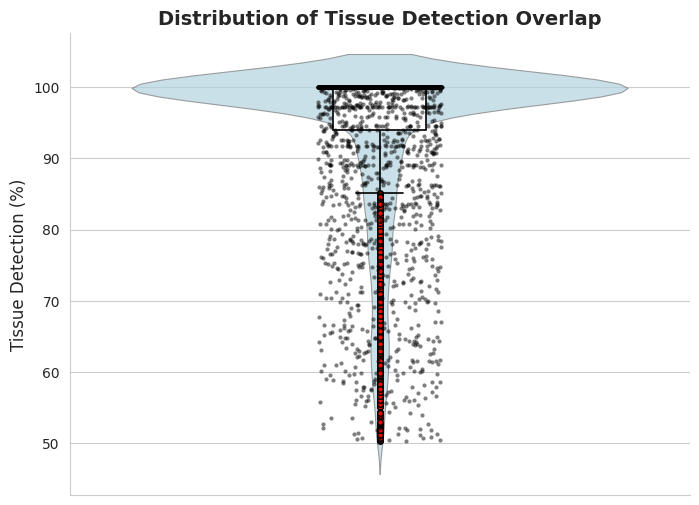

In [15]:
# Plot the distribution of tissue coverage after filtering
hm.violin_tissue_overlap(histomap_filtered)

In [16]:
# Display information about the filtered HistoMap object
print(histomap_filtered)

HistoMap Object

--------Annotation--------
📂 Annotation file used: /home/croizer/Téléchargements/QuPath-v0.5.1-Linux/Project1/AO5603_NIP_0085020_final.geojson.gz
📂 Full resolution image used: /home/croizer/Documents/Curie/ressources/4_visium_section/2_HGSOC/2_Run2_Geraldine/VISIUM2/images/AO5603_NIP_0085020.tiff
🔢 Number of annotations present: 6
🏷 Annotations: Necrosis, Negative, Positive, Stroma, Tumor, giant_cells
🏷 Activated annotations: Necrosis, giant_cells, Stroma, Tumor, Negative, Positive
🏷 Disabled annotations: 

-------Spatial Data--------
SpatialData object
├── Images
│     ├── 'AO1124_hires_image': DataArray[cyx] (3, 1970, 2000)
│     └── 'AO1124_lowres_image': DataArray[cyx] (3, 591, 600)
├── Shapes
│     └── 'AO1124': GeoDataFrame shape: (2773, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2773, 36601)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        AO1124_hires_image (Images), AO1124 (Shapes)
    ▸ 'downscaled_lowres', with elements:
 

## Exporting Filtered Data for Downstream Analysis

Now that we have filtered our data, we can export it for use in other analysis pipelines. There are several ways to do this:

1. **Export as Anndata or SpatialData**:
   - Scanpy AnnData object
   - SpatialData object

2. **Export spot metadata as csv**:
   - For use in R with Seurat
   - For other analysis platforms

3. **Save the HistoMap object**:
   - For continued analysis in the HistoMap framework

Below are examples of how to perform these exports:

1. **Export as Anndata or SpatialData**:

In [17]:
# Export as AnnData object for use with Scanpy
adata = histomap_filtered.to_anndata()
print(adata)

AnnData object with n_obs × n_vars = 2773 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region', 'Positive_overlap', 'Positive_positive', 'tissue_detection', 'Negative_overlap', 'Negative_positive'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial'


In [18]:
# Export as annotated spatialdata 
sdata = histomap_filtered.to_spatialdata()
print(sdata) 

SpatialData object
├── Images
│     ├── 'AO1124_hires_image': DataArray[cyx] (3, 1970, 2000)
│     └── 'AO1124_lowres_image': DataArray[cyx] (3, 591, 600)
├── Shapes
│     └── 'AO1124': GeoDataFrame shape: (2773, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2773, 36601)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        AO1124_hires_image (Images), AO1124 (Shapes)
    ▸ 'downscaled_lowres', with elements:
        AO1124_lowres_image (Images), AO1124 (Shapes)
    ▸ 'global', with elements:
        AO1124 (Shapes)


2. **Export spot metadata as csv**:

In [19]:
# Export spot barcodes for use with Seurat in R
df = histomap_filtered.spot_metadata_to_df()
df.to_csv('./metadata.csv')


In Seurat, you can load the csv,  
df <- read_csv('metadata.csv')  
Subset your Seurat object to keep only the tissue detected  
mySeurat <- subset(mySeurat, cells=rownames(df))  
And transfer the metadata  
mySeurat <- AddMetaData(mySeurat, df)  

3. **Save the HistoMap object**:

In [20]:
# Save the HistoMap object for later use
histomap_filtered.save("histomap_filtered.pickle")

Object saved to histomap_filtered.pickle


It can later be loaded like so 

In [21]:
histomap = hm.load_histomap("histomap_filtered.pickle")

Object loaded from histomap_filtered.pickle


In [22]:
print(histomap)

HistoMap Object

--------Annotation--------
📂 Annotation file used: /home/croizer/Téléchargements/QuPath-v0.5.1-Linux/Project1/AO5603_NIP_0085020_final.geojson.gz
📂 Full resolution image used: /home/croizer/Documents/Curie/ressources/4_visium_section/2_HGSOC/2_Run2_Geraldine/VISIUM2/images/AO5603_NIP_0085020.tiff
🔢 Number of annotations present: 6
🏷 Annotations: Necrosis, Negative, Positive, Stroma, Tumor, giant_cells
🏷 Activated annotations: Necrosis, giant_cells, Stroma, Tumor, Negative, Positive
🏷 Disabled annotations: 

-------Spatial Data--------
SpatialData object
├── Images
│     ├── 'AO1124_hires_image': DataArray[cyx] (3, 1970, 2000)
│     └── 'AO1124_lowres_image': DataArray[cyx] (3, 591, 600)
├── Shapes
│     └── 'AO1124': GeoDataFrame shape: (2773, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2773, 36601)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        AO1124_hires_image (Images), AO1124 (Shapes)
    ▸ 'downscaled_lowres', with elements:
 

## Next Steps

Now that you have filtered your spatial transcriptomics data based on tissue annotations, you can proceed with downstream analyses such as:

1. **Differential expression analysis** between annotated regions
2. **Spatial statistics** to identify spatial patterns of gene expression
3. **Cell type deconvolution** within annotated tissue regions
4. **Pathway analysis** by tissue compartment
5. **Integration with other omics data**

The HistoMap package provides a robust framework for integrating histological annotations with spatial transcriptomics data, opening up new possibilities for understanding tissue biology at the molecular level.